In [1]:
import numpy as np
import pandas as pd
from arch import arch_model
import warnings
from tqdm import tqdm
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

file_path = '/Users/mmajidov/Projects/monolith/moextrade/tables/intraday_prices.xlsx'

In [5]:
def load_and_reshape_data(file_path):
    """Load and reshape the data from the given format"""
    df = pd.read_excel(file_path, index_col=0)
    df = df.transpose()
    df.index = pd.to_datetime(df.index)

    long_data = []
    for date in df.index:
        for time in df.columns:
            price = df.loc[date, time]
            if not pd.isna(price) and price != '':
                long_data.append({
                    'datetime': pd.to_datetime(f"{date.date()} {time}"),
                    'price': float(price),
                    'date': date.date(),
                    'time': time
                })

    result_df = pd.DataFrame(long_data)
    result_df.set_index('datetime', inplace=True)
    result_df.sort_index(inplace=True)
    return result_df


def convert_to_hourly_returns(df):
    """
    Convert 5-minute data to hourly returns to reduce noise.
    Uses log returns and squares them for realized variance estimation.
    """
    df = df.copy()
    df['datetime'] = pd.to_datetime(
        df['tradedate'].astype(str) + ' ' +
        df['tradetime'].astype(str)
    )
    df.set_index('datetime', inplace=True, drop=True)
    df['log_price'] = np.log(df['pr_close'])

    # Resample to hourly, taking last price of each hour
    hourly_prices = df['log_price'].resample('h').last().dropna()
    # Calculate hourly log returns
    hourly_returns = hourly_prices.diff().dropna()
    return hourly_returns


def compute_daily_realized_variance(hourly_returns, morning_start="07:00", morning_end="11:00"):
    """
    Compute daily realized variance using squared hourly returns.
    Also computes morning portion (07:00-11:00) realized variance.

    Returns DataFrame with:
    - realized_var_day: sum of squared hourly returns for the day
    - realized_var_morning: sum of squared hourly returns for morning period
    - close_return: daily close-to-close return
    - morning_fraction: fraction of daily variance from morning
    """
    df = pd.DataFrame({'hourly_return': hourly_returns})
    df['date'] = df.index.normalize()
    df['squared_return'] = df['hourly_return'] ** 2

    morning_start_time = pd.to_datetime(morning_start).time()
    morning_end_time = pd.to_datetime(morning_end).time()

    daily_stats = []

    for date, group in df.groupby('date'):
        # Daily realized variance (sum of squared hourly returns)
        daily_var = group['squared_return'].sum()

        # Morning realized variance
        morning_mask = (group.index.time >= morning_start_time) & (group.index.time <= morning_end_time)
        morning_group = group[morning_mask]
        morning_var = morning_group['squared_return'].sum()

        # Daily return (sum of hourly returns = log(close/open))
        daily_return = group['hourly_return'].sum()

        daily_stats.append({
            'date': date,
            'realized_var_day': daily_var,
            'realized_var_morning': morning_var,
            'close_return': daily_return,
            'n_hours_day': len(group),
            'n_hours_morning': len(morning_group)
        })

    result_df = pd.DataFrame(daily_stats).set_index('date')

    # Calculate morning fraction of daily variance
    result_df['morning_fraction'] = result_df['realized_var_morning'] / result_df['realized_var_day']
    result_df['morning_fraction'] = result_df['morning_fraction'].replace([np.inf, -np.inf], np.nan)

    return result_df


def fit_garch_forecast(returns, min_obs=60, p=1, q=1):
    """
    Fit GARCH model and return one-step-ahead variance forecast
    """
    returns_clean = returns.dropna()

    if len(returns_clean) < min_obs:
        return None, "insufficient_data"

    try:
        # Fit GARCH model on daily returns
        model = arch_model(returns_clean, vol='GARCH', p=p, q=q, mean='Zero', dist='normal')
        fitted_model = model.fit(disp='off')

        # One-step ahead forecast
        forecast = fitted_model.forecast(horizon=1, reindex=False)
        forecast_var = forecast.variance.iloc[-1, 0]

        if not np.isfinite(forecast_var) or forecast_var <= 0:
            return None, "invalid_forecast"

        return forecast_var, None

    except Exception as e:
        return None, f"garch_error: {str(e)}"


def compute_volatility_forecasts(daily_data, min_train_days=60):
    """
    Compute volatility forecasts for each day using two methods:
    1. Pure GARCH forecast (day-ahead)
    2. Updated forecast using morning realized variance
    """
    dates = sorted(daily_data.index)
    results = []

    # Calculate historical morning fraction for fallback
    historical_morning_frac = daily_data['morning_fraction'].dropna()
    fallback_morning_frac = historical_morning_frac.median() if len(historical_morning_frac) > 0 else 0.25

    for i, target_date in enumerate(tqdm(dates, desc="Computing forecasts")):
        # Training data: all data before target date
        train_dates = [d for d in dates if d < target_date]

        if len(train_dates) < min_train_days:
            continue

        # Train on historical daily returns
        train_returns = daily_data.loc[train_dates, 'close_return'].dropna()

        # Fit GARCH and get day-ahead forecast
        garch_var_forecast, error = fit_garch_forecast(train_returns, min_obs=min_train_days)

        if garch_var_forecast is None:
            # Fallback to EWMA if GARCH fails
            ewma_var = train_returns.rolling(window=20).var().iloc[-1] if len(
                train_returns) >= 20 else train_returns.var()
            garch_var_forecast = ewma_var if np.isfinite(ewma_var) else daily_data['realized_var_day'].mean()

        # Calculate morning fraction from historical data
        hist_morning_fractions = daily_data.loc[train_dates, 'morning_fraction'].dropna()
        if len(hist_morning_fractions) >= 10:
            morning_frac = hist_morning_fractions.rolling(window=20).median().iloc[-1]
        else:
            morning_frac = fallback_morning_frac

        morning_frac = morning_frac if np.isfinite(morning_frac) else fallback_morning_frac

        # Predicted morning variance
        pred_morning_var = garch_var_forecast * morning_frac

        # Get actual realized variances for evaluation
        actual_daily_var = daily_data.loc[target_date, 'realized_var_day']
        actual_morning_var = daily_data.loc[target_date, 'realized_var_morning']

        # Updated forecast: replace predicted morning with actual morning
        if np.isfinite(actual_morning_var):
            remaining_var = garch_var_forecast - pred_morning_var
            remaining_var = max(remaining_var, 0)  # Ensure non-negative
            updated_var_forecast = actual_morning_var + remaining_var
        else:
            updated_var_forecast = garch_var_forecast

        results.append({
            'date': target_date,
            # Day-ahead forecasts
            'garch_var_forecast': garch_var_forecast,
            'garch_vol_forecast': np.sqrt(garch_var_forecast),
            # Updated forecasts using morning data
            'updated_var_forecast': updated_var_forecast,
            'updated_vol_forecast': np.sqrt(updated_var_forecast),
            # Actual realized values
            'actual_var_day': actual_daily_var,
            'actual_vol_day': np.sqrt(actual_daily_var) if np.isfinite(actual_daily_var) else np.nan,
            'actual_var_morning': actual_morning_var,
            'actual_vol_morning': np.sqrt(actual_morning_var) if np.isfinite(actual_morning_var) else np.nan,
            # Predicted components
            'pred_morning_var': pred_morning_var,
            'morning_frac_used': morning_frac,
            # Metadata
            'garch_error': error
        })

    return pd.DataFrame(results).set_index('date')


def evaluate_forecasts(forecast_df):
    """
    Evaluate forecast performance using various metrics
    """
    # Remove rows where actual variance is NaN
    eval_df = forecast_df.dropna(subset=['actual_var_day']).copy()

    if len(eval_df) == 0:
        print("No valid data for evaluation")
        return None

    print("=== VOLATILITY FORECAST EVALUATION ===\n")
    print(f"Evaluation period: {eval_df.index.min()} to {eval_df.index.max()}")
    print(f"Number of observations: {len(eval_df)}")
    print()

    # Variance forecasts evaluation
    print("VARIANCE FORECASTS:")
    print("-" * 50)

    # GARCH day-ahead forecasts
    var_rmse_garch = np.sqrt(mean_squared_error(eval_df['actual_var_day'], eval_df['garch_var_forecast']))
    var_mae_garch = mean_absolute_error(eval_df['actual_var_day'], eval_df['garch_var_forecast'])
    var_mape_garch = np.mean(
        np.abs((eval_df['actual_var_day'] - eval_df['garch_var_forecast']) / eval_df['actual_var_day'])) * 100

    print(f"GARCH Day-ahead Variance Forecasts:")
    print(f"  RMSE: {var_rmse_garch:.6f}")
    print(f"  MAE:  {var_mae_garch:.6f}")
    print(f"  MAPE: {var_mape_garch:.2f}%")
    print()

    # Updated forecasts using morning data
    var_rmse_updated = np.sqrt(mean_squared_error(eval_df['actual_var_day'], eval_df['updated_var_forecast']))
    var_mae_updated = mean_absolute_error(eval_df['actual_var_day'], eval_df['updated_var_forecast'])
    var_mape_updated = np.mean(
        np.abs((eval_df['actual_var_day'] - eval_df['updated_var_forecast']) / eval_df['actual_var_day'])) * 100

    print(f"Updated Variance Forecasts (using morning data):")
    print(f"  RMSE: {var_rmse_updated:.6f}")
    print(f"  MAE:  {var_mae_updated:.6f}")
    print(f"  MAPE: {var_mape_updated:.2f}%")
    print()

    # Volatility forecasts evaluation
    print("VOLATILITY FORECASTS:")
    print("-" * 50)

    # GARCH day-ahead volatility forecasts
    vol_rmse_garch = np.sqrt(mean_squared_error(eval_df['actual_vol_day'], eval_df['garch_vol_forecast']))
    vol_mae_garch = mean_absolute_error(eval_df['actual_vol_day'], eval_df['garch_vol_forecast'])
    vol_mape_garch = np.mean(
        np.abs((eval_df['actual_vol_day'] - eval_df['garch_vol_forecast']) / eval_df['actual_vol_day'])) * 100

    print(f"GARCH Day-ahead Volatility Forecasts:")
    print(f"  RMSE: {vol_rmse_garch:.6f}")
    print(f"  MAE:  {vol_mae_garch:.6f}")
    print(f"  MAPE: {vol_mape_garch:.2f}%")
    print()

    # Updated volatility forecasts
    vol_rmse_updated = np.sqrt(mean_squared_error(eval_df['actual_vol_day'], eval_df['updated_vol_forecast']))
    vol_mae_updated = mean_absolute_error(eval_df['actual_vol_day'], eval_df['updated_vol_forecast'])
    vol_mape_updated = np.mean(
        np.abs((eval_df['actual_vol_day'] - eval_df['updated_vol_forecast']) / eval_df['actual_vol_day'])) * 100

    print(f"Updated Volatility Forecasts (using morning data):")
    print(f"  RMSE: {vol_rmse_updated:.6f}")
    print(f"  MAE:  {vol_mae_updated:.6f}")
    print(f"  MAPE: {vol_mape_updated:.2f}%")
    print()

    # Improvement metrics
    print("FORECAST IMPROVEMENT:")
    print("-" * 50)

    var_rmse_improvement = ((var_rmse_garch - var_rmse_updated) / var_rmse_garch) * 100
    var_mae_improvement = ((var_mae_garch - var_mae_updated) / var_mae_garch) * 100
    vol_rmse_improvement = ((vol_rmse_garch - vol_rmse_updated) / vol_rmse_garch) * 100
    vol_mae_improvement = ((vol_mae_garch - vol_mae_updated) / vol_mae_garch) * 100

    print(f"Variance RMSE improvement: {var_rmse_improvement:.2f}%")
    print(f"Variance MAE improvement: {var_mae_improvement:.2f}%")
    print(f"Volatility RMSE improvement: {vol_rmse_improvement:.2f}%")
    print(f"Volatility MAE improvement: {vol_mae_improvement:.2f}%")
    print()

    # Statistical significance test (Diebold-Mariano test approximation)
    var_errors_garch = eval_df['actual_var_day'] - eval_df['garch_var_forecast']
    var_errors_updated = eval_df['actual_var_day'] - eval_df['updated_var_forecast']

    vol_errors_garch = eval_df['actual_vol_day'] - eval_df['garch_vol_forecast']
    vol_errors_updated = eval_df['actual_vol_day'] - eval_df['updated_vol_forecast']

    # Mean squared error differences
    var_mse_diff = var_errors_garch ** 2 - var_errors_updated ** 2
    vol_mse_diff = vol_errors_garch ** 2 - vol_errors_updated ** 2

    print("STATISTICAL TESTS:")
    print("-" * 50)
    print(f"Mean MSE difference (variance): {var_mse_diff.mean():.8f}")
    print(f"t-statistic (variance): {var_mse_diff.mean() / (var_mse_diff.std() / np.sqrt(len(var_mse_diff))):.4f}")
    print(f"Mean MSE difference (volatility): {vol_mse_diff.mean():.8f}")
    print(f"t-statistic (volatility): {vol_mse_diff.mean() / (vol_mse_diff.std() / np.sqrt(len(vol_mse_diff))):.4f}")
    print()

    print("INTERPRETATION:")
    print("-" * 50)
    print("• RMSE measures the root mean squared error between forecasts and actual values")
    print("• MAE measures the mean absolute error between forecasts and actual values")
    print("• MAPE measures the mean absolute percentage error")
    print("• Lower values indicate better forecast accuracy")
    print("• Positive improvement percentages mean the updated forecast is better")
    print("• t-statistics > 2 suggest statistically significant improvement")
    print(f"• Morning data accounts for {eval_df['morning_frac_used'].mean() * 100:.1f}% of daily variance on average")

    return {
        'var_rmse_garch': var_rmse_garch,
        'var_rmse_updated': var_rmse_updated,
        'vol_rmse_garch': vol_rmse_garch,
        'vol_rmse_updated': vol_rmse_updated,
        'var_improvement': var_rmse_improvement,
        'vol_improvement': vol_rmse_improvement
    }


def create_forecast_plots(forecast_df):
    """Create visualization plots for forecast evaluation"""
    eval_df = forecast_df.dropna(subset=['actual_var_day']).copy()

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Variance forecasts vs actual
    axes[0, 0].scatter(eval_df['actual_var_day'], eval_df['garch_var_forecast'], alpha=0.6, label='GARCH')
    axes[0, 0].scatter(eval_df['actual_var_day'], eval_df['updated_var_forecast'], alpha=0.6, label='Updated')
    axes[0, 0].plot([eval_df['actual_var_day'].min(), eval_df['actual_var_day'].max()],
                    [eval_df['actual_var_day'].min(), eval_df['actual_var_day'].max()], 'r--')
    axes[0, 0].set_xlabel('Actual Variance')
    axes[0, 0].set_ylabel('Forecasted Variance')
    axes[0, 0].set_title('Variance Forecasts vs Actual')
    axes[0, 0].legend()

    # Volatility forecasts vs actual
    axes[0, 1].scatter(eval_df['actual_vol_day'], eval_df['garch_vol_forecast'], alpha=0.6, label='GARCH')
    axes[0, 1].scatter(eval_df['actual_vol_day'], eval_df['updated_vol_forecast'], alpha=0.6, label='Updated')
    axes[0, 1].plot([eval_df['actual_vol_day'].min(), eval_df['actual_vol_day'].max()],
                    [eval_df['actual_vol_day'].min(), eval_df['actual_vol_day'].max()], 'r--')
    axes[0, 1].set_xlabel('Actual Volatility')
    axes[0, 1].set_ylabel('Forecasted Volatility')
    axes[0, 1].set_title('Volatility Forecasts vs Actual')
    axes[0, 1].legend()

    # Time series of variance
    axes[1, 0].plot(eval_df.index, eval_df['actual_var_day'], label='Actual', alpha=0.7)
    axes[1, 0].plot(eval_df.index, eval_df['garch_var_forecast'], label='GARCH Forecast', alpha=0.7)
    axes[1, 0].plot(eval_df.index, eval_df['updated_var_forecast'], label='Updated Forecast', alpha=0.7)
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].set_ylabel('Variance')
    axes[1, 0].set_title('Variance Time Series')
    axes[1, 0].legend()
    axes[1, 0].tick_params(axis='x', rotation=45)

    # Time series of volatility
    axes[1, 1].plot(eval_df.index, eval_df['actual_vol_day'], label='Actual', alpha=0.7)
    axes[1, 1].plot(eval_df.index, eval_df['garch_vol_forecast'], label='GARCH Forecast', alpha=0.7)
    axes[1, 1].plot(eval_df.index, eval_df['updated_vol_forecast'], label='Updated Forecast', alpha=0.7)
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Volatility')
    axes[1, 1].set_title('Volatility Time Series')
    axes[1, 1].legend()
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

In [3]:
print("Loading and processing data...")

# Load the raw 5-minute data
data = pd.read_excel('/Users/mikayilmajidov/Projects/Monolith_moextrade/tables/candles.xlsx', index_col=None)
# data = load_and_reshape_data(file_path)
print(f"Loaded {len(data)} 5-minute observations")
print(f"Date range: {data.index.min()} to {data.index.max()}")

Loaded 118265 5-minute observations
Date range: 0 to 118264


In [6]:
# Convert to hourly returns to reduce noise
hourly_returns = convert_to_hourly_returns(data)
hourly_returns = hourly_returns[hourly_returns.index >= '2023-01-01']
print(f"Converted to {len(hourly_returns)} hourly returns")

# Compute daily realized variances
daily_data = compute_daily_realized_variance(hourly_returns)
print(f"Computed daily statistics for {len(daily_data)} days")

# Compute forecasts
print("Computing GARCH forecasts...")
forecast_results = compute_volatility_forecasts(daily_data, min_train_days=60)

print(f"Generated forecasts for {len(forecast_results)} days")

# Save results
# output_path = "/Users/mmajidov/Projects/monolith/moextrade/tables/garch_volatility_forecasts.xlsx"
# forecast_results.to_excel(output_path)
# print(f"Results saved to: {output_path}")

# Evaluate forecasts
evaluation_metrics = evaluate_forecasts(forecast_results)

# Display sample results
print("\nSample forecast results:")
print(forecast_results.head(10)[['garch_vol_forecast', 'updated_vol_forecast', 'actual_vol_day']].round(6))


Sample forecast results:
            garch_vol_forecast  updated_vol_forecast  actual_vol_day
date                                                                
2023-03-30            0.007712              0.006741        0.005407
2023-03-31            0.007576              0.005396        0.005270
2023-04-03            0.007701              0.007361        0.008906
2023-04-04            0.008201              0.011438        0.010950
2023-04-05            0.008161              0.007680        0.005831
2023-04-06            0.008122              0.006908        0.008274
2023-04-07            0.010223              0.016863        0.023632
2023-04-10            0.008828              0.012381        0.011000
2023-04-11            0.007789              0.007071        0.004664
2023-04-12            0.008678              0.008537        0.006613


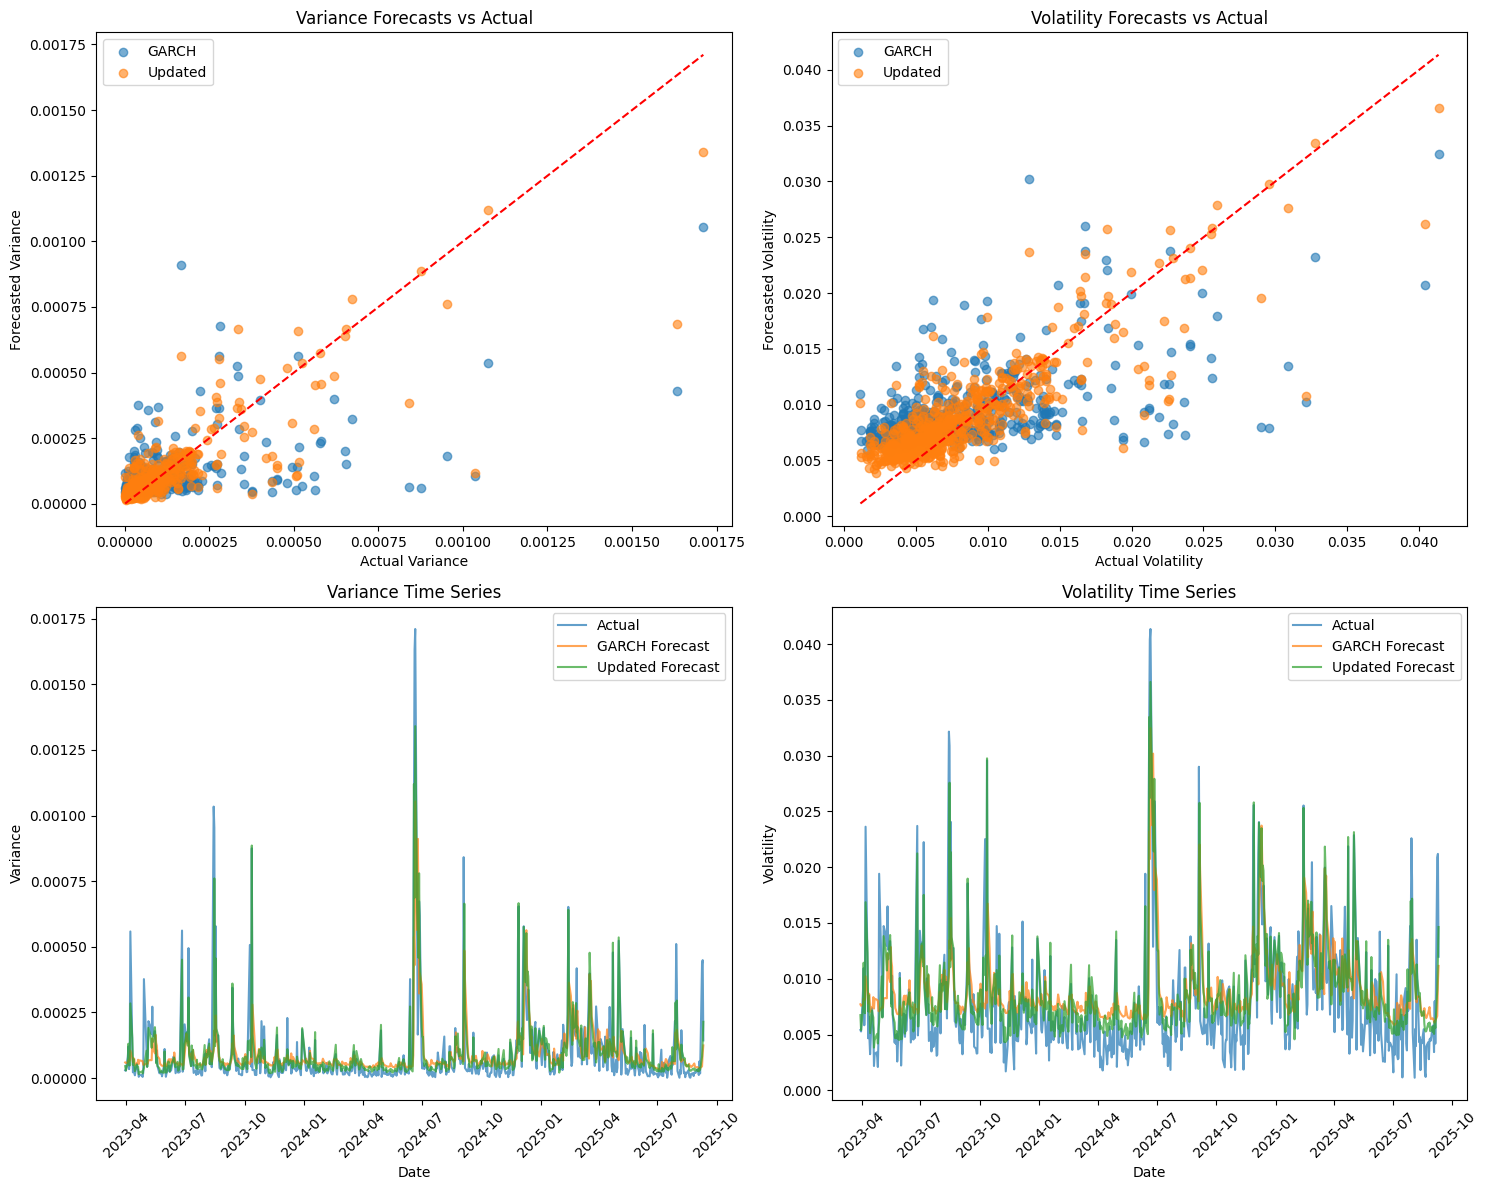

In [7]:
# Create plots
create_forecast_plots(forecast_results)